# Workflow: Abstraction Refinement

We want to compute an optimal policy for a continuous environment using a model checker. 
For that we use `verigym`'s discretization and abstraction learning features.

- We discretize the original environment
- Learn abstract (discretized) model
- Compute optimal policy using `stormpy`
- Evaluate the computed policy on the original environment
- If the performance is not yet sufficient, refine the abstraction parameters (discretization parameters) and restart.

In [5]:
from typing import Callable

import gymnasium as gym
import numpy as np
import stormpy

import verigym
from verigym.abstraction.abstractionmapper import linspace_mapper
from verigym.abstraction.learn_abstraction import create_abstraction
from verigym.policy.randomized import RandomizedPolicy
from verigym.frameworks.stormpy.stormpy_utils import build_stormpy_mdp
from verigym.abstraction.gym_utils.transform_observation import ReplaceInfObservation

In [6]:
# These functions are essential and should be part of verigym!!

# def mean_reward_trajectories(trajectories: list):
#     rewards = []
#     for trajectory in trajectories:
#         trajectory_rewards = list(map(lambda tup: tup[2], trajectory))
#         rewards.append(np.sum(trajectory_rewards))
#     return float(np.mean(rewards)) 

def mean_reward_trajectories(trajectories: list) -> tuple[float, float]:
    returns = [sum(reward for _, _, reward, *_ in trajectory) for trajectory in trajectories]
    return np.mean(returns), np.std(returns)


In [7]:
# Schedule
def schedule(args):
    """Returns a schedule for the abstraction refinement"""
    ...
    
def metric_callback(env: verigym.VeriGymEnv, policy: verigym.PolicyClass) -> bool:
    """
    After an abstraction, takes the results and checks whether the result is good enough wrt to the metric of interest. Here, performance on original environment.
    """
    EVAL_STEPS = 1000
    THRESHOLD = 400
    mean, std = evaluate_policy(env, policy, EVAL_STEPS)
    
    return mean >= THRESHOLD
    
    
    
def abstract(original_env, abstraction_mapper, num_steps):
    """Performs one abstraction based on the parameters given by the schedule."""
    abstracted_model = create_abstraction(
        original_env=original_env, 
        abstraction_mapper=abstraction_mapper, 
        exploration_policy=RandomizedPolicy(original_env),
        num_steps=num_steps,
    )

    policy_on_original, policy_on_abstracted = optimal_policy_via_model_checking(abstracted_model)
    
    return abstracted_model, policy_on_original, policy_on_abstracted
    
    
def evaluate_policy(model: verigym.VeriGymEnv, policy: verigym.PolicyClass, n_steps: int) -> tuple[float, float]:
    """Takes a policy and an environment and does the rollouts on that environment and checks its performance."""
    trajectories = model.simulate(
        policy=policy,
        n_steps=n_steps,
        verbose=False
    )
    mean, std = mean_reward_trajectories(trajectories)
    return mean, std

    
    
def optimal_policy_via_model_checking(env: verigym.ExplicitEnv):
    """We compute the optimal policy using the model checker `stormpy`. We set the discount factor to `0.95`."""
    stormpy_mdp = build_stormpy_mdp(env)
    gamma = 0.95  # discount factor
    prop = stormpy.parse_properties(f"Rmax=?[Cdiscount={gamma}]")[
        0
    ]  # checking for cumulative discounted reward

    # Run the model checking:
    result = stormpy.check_model_sparse(stormpy_mdp, prop, extract_scheduler=True)
    scheduler = result.scheduler
    
    # policy that can be execured on original model
    policy_on_original = verigym.StormpyPolicy(scheduler, env.abstraction_map, stormpy_mdp)
    
    # policy that can be execute on the abstracted model
    identity_mapper = verigym.AbstractionMapper.initialize_identity_mapper(env.observation_space, env.action_space)
    policy_on_abstracted = verigym.StormpyPolicy(
        policy=scheduler, 
        abstraction_mapper=identity_mapper,
        mdp=stormpy_mdp
        )
    return policy_on_original, policy_on_abstracted


def abstraction_refinement(
    original_env: verigym.GenerativeEnv,
    mapper_schedule: list,
    num_steps: int,
    eval_steps: int,
    earlystopping_callback: Callable,
) -> list[tuple[tuple[list[tuple[float, float]], verigym.ExplicitEnv, verigym.StormpyPolicy]]]:
    """Iteratively gets discretization parameters from `schedule` then performs an `abstract` step, then executes callback, which decides whether we continue."""
    assert (len(mapper_schedule) > 0), f"mapper_schedule have at least one entry."
    
    results = []

    for i, mapper in enumerate(mapper_schedule):
        print(f"====== Iteration {i}/{len(mapper_schedule)} ======")
        abstracted_model, policy_on_original, policy_on_abstracted = abstract(original_env, mapper, num_steps)

        original_mean, original_std = evaluate_policy(original_env, policy_on_original, eval_steps)
        abstract_mean, abstract_std = evaluate_policy(abstracted_model, policy_on_abstracted, eval_steps)
        print(f"Avg Reward on original_env: {original_mean:.2f} ± {original_std:.2f}")
        print(f"Avg Reward on abstract_env: {abstract_mean:.2f} ± {abstract_std:.2f}")
        
        results.append(((original_mean, original_std), abstracted_model, policy_on_original))

        task_complete = earlystopping_callback(original_env, policy_on_original)

        if task_complete:
            print("Finishing, we hit the threshold.")
            break
        else:
            print(f"Task complete: {task_complete}")

    return results

In [8]:
N_BINS = [2*i for i in range(1,10)]
N_BINS.append(30)
NUM_STEPS = int(1e5)
EVAL_STEPS = int(1e4)
env = gym.make("MountainCarContinuous-v0")
env = gym.make("CartPole-v1")
env = ReplaceInfObservation(env, neg_inf=-5, pos_inf=5)
original_env = verigym.GenerativeEnv.from_gymnasium(env)

# abstraction_mapper = linspace_mapper(env, n_bins_states=N_BINS, n_bins_actions=2)

mapper_schedule = [linspace_mapper(env, n_bin, 2) for n_bin in N_BINS]

results = abstraction_refinement(original_env, mapper_schedule, NUM_STEPS, EVAL_STEPS, metric_callback) # policy_results, abstracted_model, policy_on_original

policy_results = [x[0] for x in results]
# Print results
print("\n====== RESULTS ======")
for i, (mean, std) in enumerate(policy_results):
    print(f"Iteration {i}:\t{mean:.2f} ± {std:.2f}")

====== Iteration 0/10 ======
Simulation time: 0.7935s
Trajectories in dataset: 4514
processing in  2.5012784004211426
aggregating..
aggregating in 0.005278825759887695
Learning Abstraction: 2.5095s
Avg Reward on original_env: 90.91 ± 74.10
Avg Reward on abstract_env: 10000.00 ± 0.00
Task complete: False
====== Iteration 1/10 ======
Simulation time: 0.7672s
Trajectories in dataset: 4509
processing in  2.045544147491455
aggregating..
aggregating in 0.0014908313751220703
Learning Abstraction: 2.0490s
Avg Reward on original_env: 172.41 ± 55.45
Avg Reward on abstract_env: 50.00 ± 52.17
Task complete: False
====== Iteration 2/10 ======
Simulation time: 0.7909s
Trajectories in dataset: 4495
processing in  2.1792168617248535
aggregating..
aggregating in 0.0024819374084472656
Learning Abstraction: 2.1852s
Avg Reward on original_env: 94.34 ± 70.44
Avg Reward on abstract_env: 10000.00 ± 0.00
Task complete: False
====== Iteration 3/10 ======
Simulation time: 0.7616s
Trajectories in dataset: 4508
p

[Text(0, 0.5, 'Return'), Text(0.5, 0, 'N_BINS')]

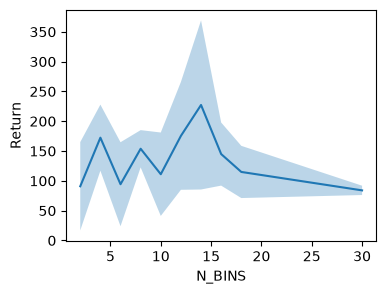

In [9]:
import matplotlib.pyplot as plt

# Data Preparation
means = np.array([y[0] for y in policy_results])
stds = np.array([y[1] for y in policy_results])
bins = N_BINS[:len(means)]
# Actual figure
fig, ax = plt.subplots(figsize=(4,3))
ax.plot(bins, means)
ax.fill_between(bins, means-stds, means+stds, alpha=0.3)
ax.set(ylabel="Return", xlabel="N_BINS")
#
